In [1]:
#importing Libraries

import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split,GridSearchCV

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score


In [2]:
#Loading Datasets

df = pd.read_csv('DataCoSupplyChainDataset.csv', encoding='latin1')
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [3]:
# collection of data

features = [
    "Days for shipping (real)",
    "Days for shipment (scheduled)",
    "Benefit per order",
    "Sales per customer",
    "Product Price"
]

X = df[features].values          
y = df["Late_delivery_risk"].values

In [4]:
# Data Preprocessing

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=5)
X_reduced = pca.fit_transform(X_scaled)

In [5]:
#Configuaration of Data

sizes=[400,1800,4000,18000]
knn_acc,rf_acc,svm_acc=[],[],[]
knn_time,rf_time,svm_time=[],[],[]


In [6]:
# Training of Model

for size in sizes:
    X_sub = X[:size]
    y_sub = y[:size]

    X_train, X_test, y_train, y_test = train_test_split(
        X_sub, y_sub, test_size=0.2, random_state=42
    )

    # -------- KNN Grid Search --------
    knn_params = {"n_neighbors": [3,5,7,9]}
    knn_grid = GridSearchCV(KNeighborsClassifier(), knn_params, cv=3, n_jobs=-1)

    start = time.time()
    knn_grid.fit(X_train, y_train)
    knn_time.append(time.time() - start)

    print(f"KNN finished | size={size} | time={knn_time[-1]:.2f} sec")

    y_pred = knn_grid.best_estimator_.predict(X_test)
    knn_acc.append(accuracy_score(y_test, y_pred))


    # -------- RF Grid Search --------
    rf_params = {"n_estimators":[50,100], "max_depth":[5,10]}
    rf_grid = GridSearchCV(RandomForestClassifier(), rf_params, cv=3, n_jobs=-1)

    start = time.time()
    rf_grid.fit(X_train, y_train)
    rf_time.append(time.time() - start)

    print(f"RF finished | size={size} | time={rf_time[-1]:.2f} sec")

    y_pred = rf_grid.best_estimator_.predict(X_test)
    rf_acc.append(accuracy_score(y_test, y_pred))


    # -------- SVM Grid Search --------
    svm_params = {"C":[0.1,1,10], "kernel":["linear","rbf","poly"]}
    svm_grid = GridSearchCV(SVC(), svm_params, cv=3, n_jobs=-1)

    start = time.time()
    svm_grid.fit(X_train, y_train)
    svm_time.append(time.time() - start)

    print(f"SVM finished | size={size} | time={svm_time[-1]:.2f} sec")

    y_pred = svm_grid.best_estimator_.predict(X_test)
    svm_acc.append(accuracy_score(y_test, y_pred))

KNN finished | size=400 | time=13.45 sec
RF finished | size=400 | time=1.01 sec
SVM finished | size=400 | time=32.02 sec
KNN finished | size=1800 | time=0.06 sec
RF finished | size=1800 | time=0.67 sec
SVM finished | size=1800 | time=189.18 sec
KNN finished | size=4000 | time=0.07 sec
RF finished | size=4000 | time=1.09 sec
SVM finished | size=4000 | time=310.54 sec
KNN finished | size=18000 | time=0.35 sec
RF finished | size=18000 | time=3.20 sec
SVM finished | size=18000 | time=1479.15 sec


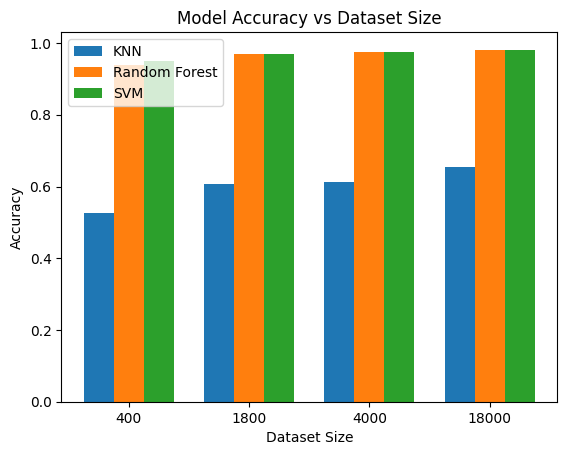

In [7]:
# Visual Representation of Accuracy Comparison

x = np.arange(len(sizes))
width = 0.25

plt.figure()

plt.bar(x - width, knn_acc, width, label="KNN")
plt.bar(x, rf_acc, width, label="Random Forest")
plt.bar(x + width, svm_acc, width, label="SVM")

plt.xticks(x, sizes)
plt.xlabel("Dataset Size")
plt.ylabel("Accuracy")
plt.title("Model Accuracy vs Dataset Size")
plt.legend()

plt.show()

In [8]:
#Size corrcetion

knn_time = knn_time[:len(sizes)]
rf_time  = rf_time[:len(sizes)]
svm_time = svm_time[:len(sizes)]

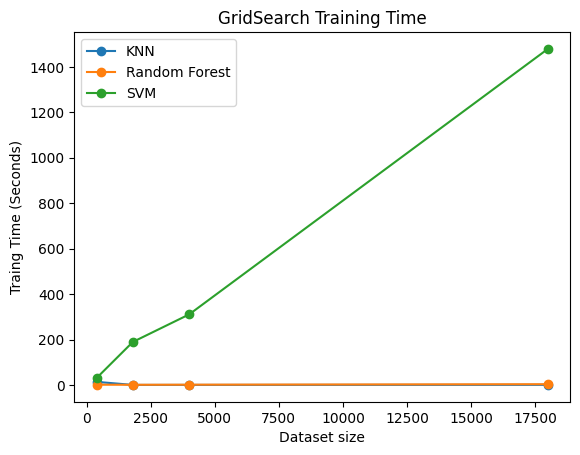

In [9]:
# Visual Representation of Training Time Comparison

plt.figure()
plt.plot(sizes,knn_time,marker='o',label="KNN")
plt.plot(sizes,rf_time,marker='o',label="Random Forest")
plt.plot(sizes,svm_time,marker='o',label="SVM")

plt.xlabel("Dataset size")
plt.ylabel("Traing Time (Seconds)")
plt.title("GridSearch Training Time")
plt.legend()
plt.show()